# Data Preprocessing Exercises
### Dataset: Football Players Dataset

**Dataset Url**: https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/fundamentals/football_players.csv


### Task Overview: Data Preprocessing Exercises

In this Exercise, you will practice essential data preprocessing techniques using the **football_players.csv** dataset. The exercises are designed to guide you through the key steps of data cleaning, feature selection, data transformation, and dimensionality reduction. These techniques are fundamental for preparing data for machine learning models, ensuring that the data is clean, relevant, and in an optimal format for analysis. By completing this task, you will gain hands-on experience in handling real-world datasets, improving their quality and reducing complexity, ultimately enhancing model performance.

In [1]:
import pandas as pd

# 1. Load the dataset
url = "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/fundamentals/football_players.csv"
df = pd.read_csv(url)

# Display the first few rows of the dataset
df

C:\Users\Moussa\AppData\Local\Temp\ipykernel_5324\1543975746.py:5: DtypeWarning: Columns (14,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,Name,Age,Nationality,Overall,Acceleration,Aggression,Agility,Balance,Ball control,Composure,...,Short passing,Shot power,Sliding tackle,Sprint speed,Stamina,Standing tackle,Strength,Vision,Volleys,Preferred Positions
0,Cristiano Ronaldo,32,Portugal,94,89,63,89,63,93,95,...,83,94,23,91,92,31,80,85,88,ST LW
1,L. Messi,30,Argentina,93,92,48,90,95,95,96,...,88,85,26,87,73,28,59,90,85,RW
2,Neymar,25,Brazil,92,94,56,96,82,95,92,...,81,80,33,90,78,24,53,80,83,LW
3,L. Suárez,30,Uruguay,92,88,78,86,60,91,83,...,83,87,38,77,89,45,80,84,88,ST
4,M. Neuer,31,Germany,92,58,29,52,35,48,70,...,55,25,11,61,44,10,83,70,11,GK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17976,A. Kelsey,17,England,46,24,16,38,26,12,23,...,19,19,10,32,28,11,50,26,6,GK
17977,B. Richardson,47,England,46,25,44,35,44,22,44,...,12,13,13,25,32,12,47,17,12,GK
17978,J. Young,17,Scotland,46,66,26,60,77,41,50,...,42,42,14,51,33,17,32,37,33,ST
17979,J. Lundstram,18,England,46,57,46,58,74,43,45,...,49,43,47,58,49,48,46,51,25,CM


### Section 1: Data Cleaning


#### Exercise 1.1: Basic Data Inspection
- Load the dataset into a pandas DataFrame.
- Check the data types of each column.
- Find and display any duplicate rows.
- Remove any duplicates (if present).

*Hint:* Use pandas functions like pd.read_csv(), df.dtypes, and df.duplicated().



In [2]:
data_types = df.dtypes
print(data_types)

Name                   object
Age                     int64
Nationality            object
Overall                 int64
Acceleration           object
Aggression             object
Agility                object
Balance                object
Ball control           object
Composure              object
Crossing               object
Curve                  object
Dribbling              object
Finishing              object
Free kick accuracy     object
GK diving              object
GK handling            object
GK kicking             object
GK positioning         object
GK reflexes            object
Heading accuracy       object
Interceptions          object
Jumping                object
Long passing           object
Long shots             object
Marking                object
Penalties              object
Positioning            object
Reactions              object
Short passing          object
Shot power             object
Sliding tackle         object
Sprint speed           object
Stamina   

In [3]:
duplicates = df[df.duplicated()]
print(duplicates)

                Name  Age    Nationality  Overall Acceleration Aggression  \
804        D. Heintz   23        Germany       78       55         70       
805          Pozuelo   25          Spain       78       62         52       
809      M. Sabitzer   23        Austria       78       87         69       
810             Capa   25          Spain       78       85         88       
815      C. Aránguiz   28          Chile       78       77         68       
816       V. Rongier   22         France       78       69         51       
818       J. Lingard   24        England       78       84         66       
820     A. Marchesín   29      Argentina       78       49         27       
822           Danilo   25         Brazil       78       75         74       
824       O. Al Soma   28          Syria       78       74         67       
826            Bigas   26          Spain       78       71         89       
827         D. Origi   22        Belgium       78       82         69       

In [4]:
df_cleaned = df.drop_duplicates()
print(df_cleaned)

                    Name  Age Nationality  Overall Acceleration Aggression  \
0      Cristiano Ronaldo   32    Portugal       94       89         63       
1               L. Messi   30   Argentina       93       92         48       
2                 Neymar   25      Brazil       92       94         56       
3              L. Suárez   30     Uruguay       92       88         78       
4               M. Neuer   31     Germany       92       58         29       
...                  ...  ...         ...      ...          ...        ...   
17976          A. Kelsey   17     England       46       24         16       
17977      B. Richardson   47     England       46       25         44       
17978           J. Young   17    Scotland       46       66         26       
17979       J. Lundstram   18     England       46       57         46       
17980          L. Sackey   18       Ghana       46       48         52       

      Agility Balance Ball control Composure  ... Short passing

#### Exercise 1.2: Handling Outliers
- Identify outliers in numerical columns such as 'Age', 'Overall', 'Acceleration', and 'Aggression' using statistical methods (e.g., IQR or Z-score).
- Handle the outliers by either capping them or removing the affected rows.

*Hint:* Use IQR and Z-score techniques with functions like np.percentile(), scipy.stats.zscore(), etc.

In [5]:
import numpy as np
from scipy import stats
columns_check = ['Age', 'Overall', 'Acceleration', 'Aggression']
def handle_outliers(df, columns, method='iqr'):
    df_out = df.copy()
    for column in columns:
        if not pd.api.types.is_numeric_dtype(df_out[column]):
            print(f"Skipping non-numeric column: {column}")
            continue
        if method == 'iqr':
            Q1 = df_out[column].quantile(0.25)
            Q3 = df_out[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df_out[column] = np.clip(df_out[column], lower_bound, upper_bound)
        elif method == 'zscore':
            z_scores = stats.zscore(df_out[column])
            abs_z_scores = np.abs(z_scores)
            df_out = df_out[abs_z_scores < 3]
    return df_out

In [6]:
df_iqr_handled = handle_outliers(df, columns_check, method='iqr')
print("\nDataFrame after handling outliers using the IQR :")
print(df_iqr_handled.describe())

Skipping non-numeric column: Acceleration
Skipping non-numeric column: Aggression

DataFrame after handling outliers using the IQR :
                Age       Overall
count  17981.000000  17981.000000
mean      25.141316     66.237834
std        4.603626      6.941054
min       16.000000     48.500000
25%       21.000000     62.000000
50%       25.000000     66.000000
75%       28.000000     71.000000
max       38.500000     84.500000


In [7]:
df_zscore_handled = handle_outliers(df, columns_check, method='zscore')
print("\nDataFrame after handling outliers using the Z-score :")
print(df_zscore_handled.describe())

Skipping non-numeric column: Acceleration
Skipping non-numeric column: Aggression

DataFrame after handling outliers using the Z-score :
                Age       Overall
count  17913.000000  17913.000000
mean      25.108301     66.206498
std        4.569362      6.922662
min       16.000000     46.000000
25%       21.000000     62.000000
50%       25.000000     66.000000
75%       28.000000     71.000000
max       38.000000     87.000000


### Section 2: Feature Selection


#### Exercise 2.1: Feature Correlation
- Calculate the correlation matrix for numerical features (e.g., Overall, Acceleration, Agility, etc.).
- Visualize the correlations using a heatmap.
- Identify and drop features that are highly correlated with each other (correlation > 0.85).

*Hint:* Use df.corr() for correlation and seaborn.heatmap() for visualization

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

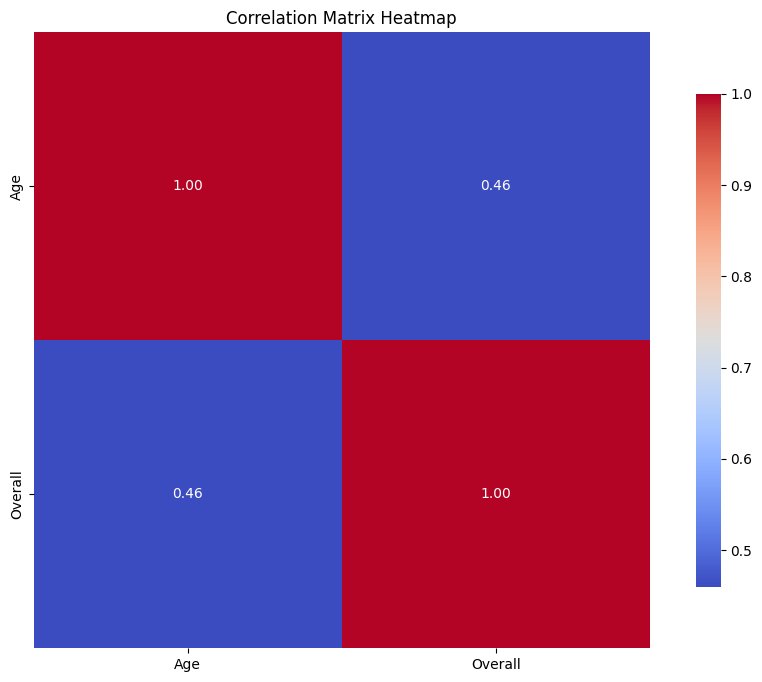

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix Heatmap')
plt.show()

In [11]:
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.85:
            colname = corr_matrix.columns[i]
            high_corr_pairs.append((corr_matrix.columns[j], colname))

print("Highly correlated pairs (correlation > 0.85):")
print(high_corr_pairs)

Highly correlated pairs (correlation > 0.85):
[]


In [12]:
for (col1, col2) in high_corr_pairs:
    if col2 in numeric_df.columns:
        numeric_df = numeric_df.drop(col2, axis=1)

print("\nRemaining columns after dropping highly correlated features:")
print(numeric_df.columns)


Remaining columns after dropping highly correlated features:
Index(['Age', 'Overall'], dtype='object')


#### Exercise 2.2: Feature Importance
- Use a feature importance method, such as Random Forest or Decision Trees, to rank the features based on their contribution to predicting a target variable (e.g., 'Overall').
- Select the top 10 most important features for further analysis.

*Hint:* Use sklearn.ensemble.RandomForestRegressor or sklearn.tree.DecisionTreeRegressor for feature ranking.



In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
X = numeric_df.drop(columns=['Overall'])
y = numeric_df['Overall']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [14]:
feature_importances = model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

In [15]:
top_10_features = importance_df.head(10)
print("Top 10 Most Important Features:")
print(top_10_features)

Top 10 Most Important Features:
  Feature  Importance
0     Age         1.0


### Section 3: Data Transformation

#### Exercise 3.1: Scaling Numerical Features
- Apply scaling techniques (Standardization or Min-Max Scaling) to numerical features such as 'Age', 'Overall', 'Acceleration', etc.
- Compare the distribution of the original and scaled features using histograms.

*Hint:* Use sklearn.preprocessing.StandardScaler or MinMaxScaler.

In [16]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
features_to_scale = ['Age', 'Overall', 'Acceleration', 'Agility', 'Aggression']  # Example features
features_to_scale = [feature for feature in features_to_scale if feature in numeric_df.columns]
data_to_scale = numeric_df[features_to_scale]

In [17]:
scaler_standard = StandardScaler()
data_standard_scaled = scaler_standard.fit_transform(data_to_scale)
scaler_minmax = MinMaxScaler()
data_minmax_scaled = scaler_minmax.fit_transform(data_to_scale)
data_standard_scaled_df = pd.DataFrame(data_standard_scaled, columns=features_to_scale)
data_minmax_scaled_df = pd.DataFrame(data_minmax_scaled, columns=features_to_scale)

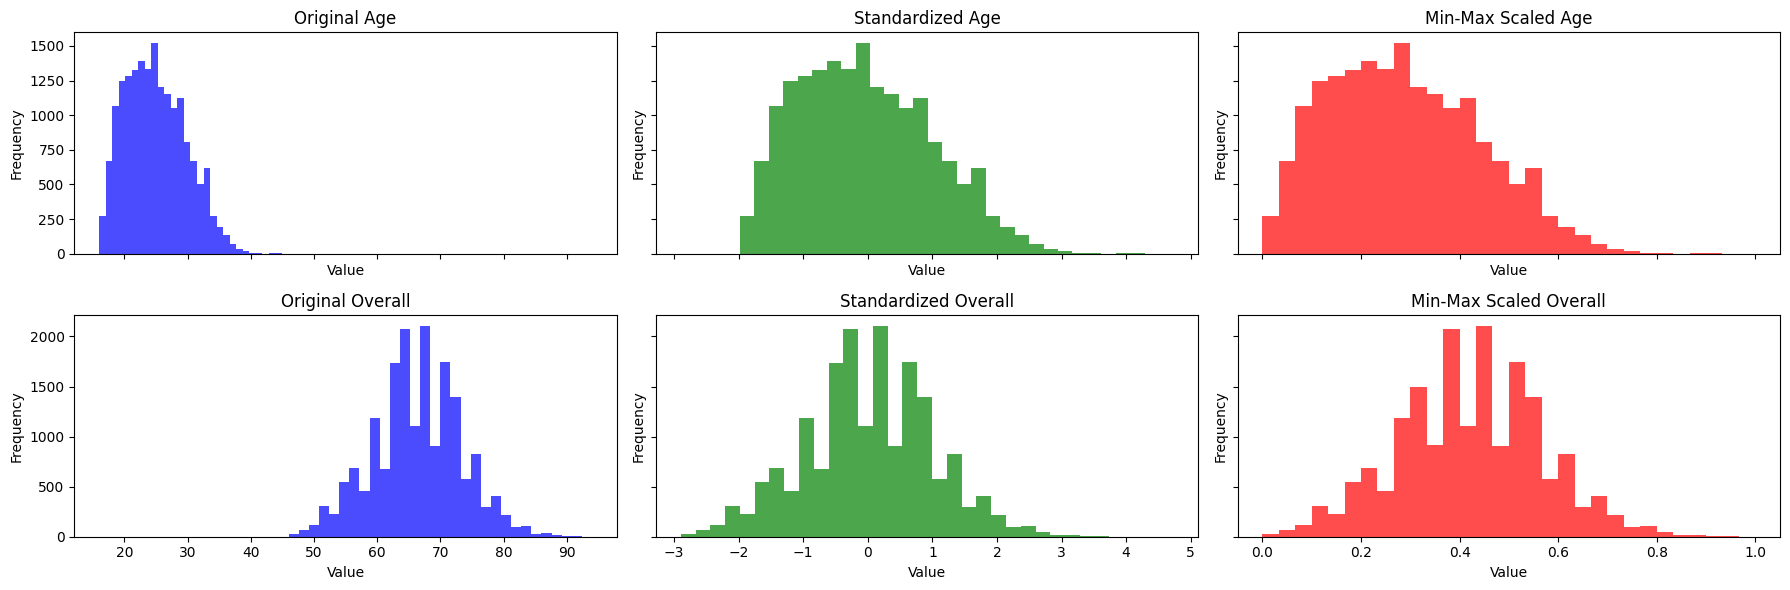

In [18]:
fig, axs = plt.subplots(len(features_to_scale), 3, figsize=(18, 3 * len(features_to_scale)), sharex='col', sharey='row')

for i, feature in enumerate(features_to_scale):
    axs[i, 0].hist(data_to_scale[feature], bins=30, color='blue', alpha=0.7)
    axs[i, 0].set_title(f'Original {feature}')
    axs[i, 0].set_xlabel('Value')
    axs[i, 0].set_ylabel('Frequency')

    axs[i, 1].hist(data_standard_scaled_df[feature], bins=30, color='green', alpha=0.7)
    axs[i, 1].set_title(f'Standardized {feature}')
    axs[i, 1].set_xlabel('Value')
    axs[i, 1].set_ylabel('Frequency')

    axs[i, 2].hist(data_minmax_scaled_df[feature], bins=30, color='red', alpha=0.7)
    axs[i, 2].set_title(f'Min-Max Scaled {feature}')
    axs[i, 2].set_xlabel('Value')
    axs[i, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Exercise 3.2: Encoding Categorical Variables
- Convert categorical columns like 'Preferred Positions' into numerical representations using techniques like One-Hot Encoding.
- Drop the original categorical columns after encoding.

*Hint:* Use pd.get_dummies() for one-hot encoding.



In [19]:
categorical_columns = ['Preferred Positions']
categorical_columns = [col for col in categorical_columns if col in df.columns]
df_encoded = pd.get_dummies(df, columns=categorical_columns)
print("DataFrame after One-Hot Encoding:")
print(df_encoded.head())

DataFrame after One-Hot Encoding:
                Name  Age Nationality  Overall Acceleration Aggression  \
0  Cristiano Ronaldo   32    Portugal       94       89         63       
1           L. Messi   30   Argentina       93       92         48       
2             Neymar   25      Brazil       92       94         56       
3          L. Suárez   30     Uruguay       92       88         78       
4           M. Neuer   31     Germany       92       58         29       

  Agility Balance Ball control Composure  ... Preferred Positions_ST RM CF   \
0  89      63           93        95      ...                         False   
1  90      95           95        96      ...                         False   
2  96      82           95        92      ...                         False   
3  86      60           91        83      ...                         False   
4  52      35           48        70      ...                         False   

  Preferred Positions_ST RM LM  Preferred Posi

### Section 4: Dimensionality Reduction


#### Exercise 4.1: Principal Component Analysis (PCA)
- Apply PCA to the scaled numerical data and reduce the dimensionality to explain at least 90% of the variance.
- Visualize the explained variance ratio for each principal component.

*Hint:* Use sklearn.decomposition.PCA().

In [20]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
features_to_scale = ['Age', 'Overall', 'Acceleration', 'Agility', 'Aggression']
features_to_scale = [feature for feature in features_to_scale if feature in numeric_df.columns]
data_to_scale = numeric_df[features_to_scale]

In [21]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_to_scale)
pca = PCA()
data_pca = pca.fit_transform(data_scaled)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
n_components = np.argmax(cumulative_variance_ratio >= 0.90) + 1
print(f"Number of components explaining at least 90% of the variance: {n_components}")

Number of components explaining at least 90% of the variance: 2


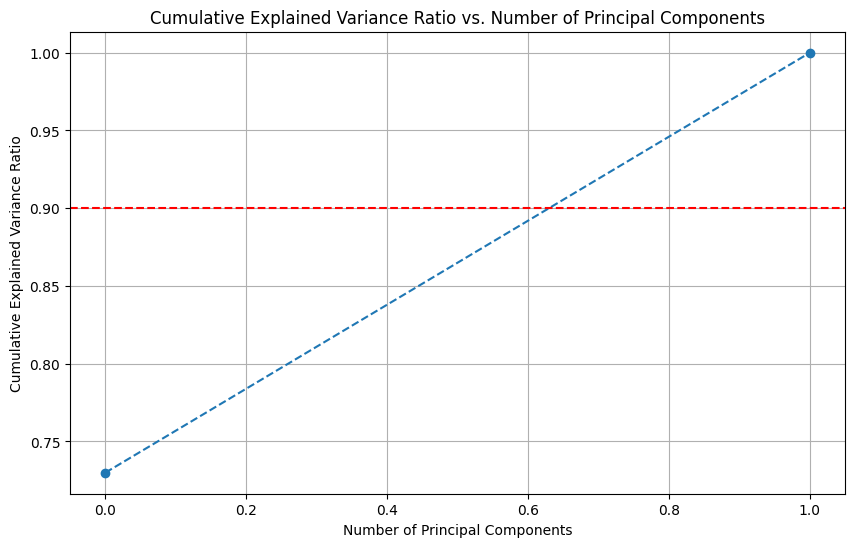

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance_ratio, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio vs. Number of Principal Components')
plt.grid(True)
plt.show()

#### Exercise 4.2: Feature Selection via Lasso
- Use Lasso Regression to perform feature selection and reduce the number of features.
- Choose the features with non-zero coefficients and visualize their importance.

*Hint:* Use sklearn.linear_model.Lasso.

In [23]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
features = numeric_df.drop(columns=['Overall'])
target = numeric_df['Overall']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
lasso = Lasso(alpha=0.1)
lasso.fit(features_scaled, target)
feature_names = features.columns
coefficients = lasso.coef_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

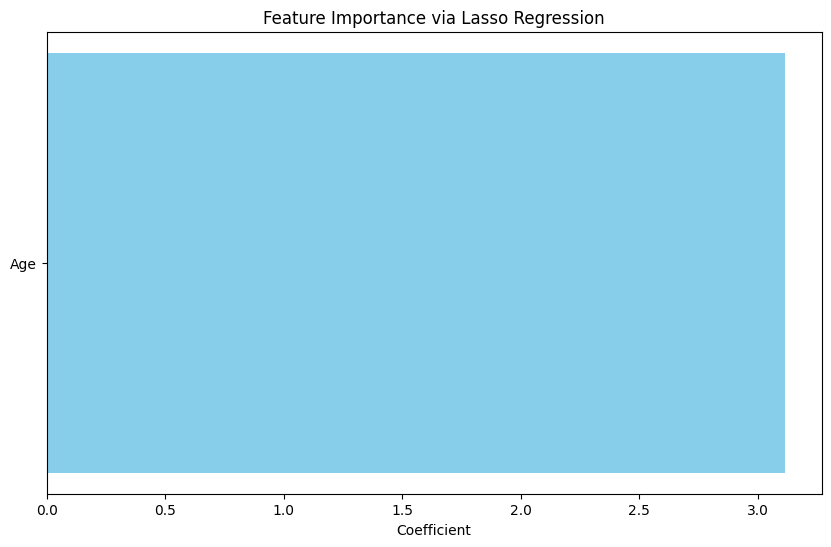

Features with non-zero coefficients:
  Feature  Coefficient
0     Age     3.112732


In [24]:
non_zero_importance_df = importance_df[importance_df['Coefficient'] != 0]
plt.figure(figsize=(10, 6))
plt.barh(non_zero_importance_df['Feature'], non_zero_importance_df['Coefficient'], color='skyblue')
plt.xlabel('Coefficient')
plt.title('Feature Importance via Lasso Regression')
plt.show()

print("Features with non-zero coefficients:")
print(non_zero_importance_df)

# End of Exercises!